In [2]:
import math
import numpy as np
import bearing_simulation
import matplotlib.pyplot as plt
import matplotlib as mpl
import itertools 
import pandas as pd
from matplotlib.ticker import MultipleLocator

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm
from collections import defaultdict
from scipy.stats import norm
from IPython.display import clear_output

In [3]:
def create_targets_on_arc(n, angular_separation, radius):
    """
    Create evenly spaced targets on an arc.
    """
    targets = []
    start = -((n - 1) / 2) * angular_separation
    for i in range(n):
        offset = start + i * angular_separation
        targets.append((radius * math.cos(offset), radius * math.sin(offset)))
    return targets

def plot_entities(observers, targets):
    fig, ax = plt.subplots(figsize=(6, 6))
    ox, oy, _ = zip(*observers)
    ax.scatter(ox, oy, label="Tarkastelijat", marker="o")

    for i, group in enumerate(targets):
        tx, ty = zip(*group)
        ax.scatter(tx, ty, marker="x", label="Kohteet")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)

    return fig, ax

# One observer, two targets

Scenario with a single observer with two targets. Visualizes the effect that target separation has on the association accuracy, as we gradually move the targets further apart. 

In [4]:
observer_std =  math.radians(1)
observers = [(0, 0, observer_std)]
target_separations = np.linspace(0.0, math.pi / 32)
targets = [create_targets_on_arc(2, ts, 1.0) for ts in target_separations]
trials = 10000

In [5]:
accuracy_data = []

for ts in targets:
    (success_rate, _) = bearing_simulation.monte_carlo(observers, ts, trials, "hungarian")
    accuracy_data.append(success_rate)

analytical_accuracy_data = norm.cdf(target_separations / (math.sqrt(2) * observer_std)) 

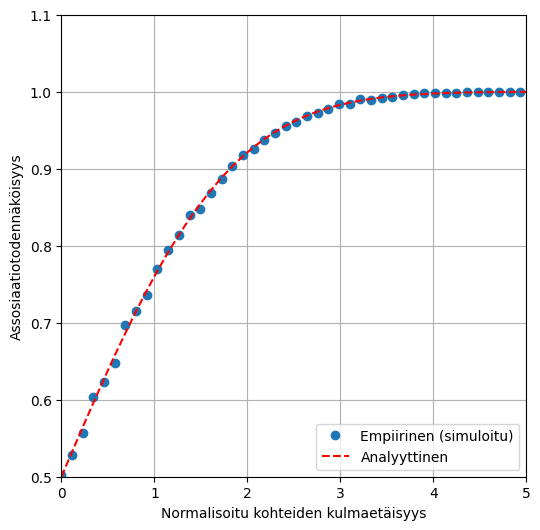

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(target_separations / observer_std, accuracy_data, marker="o", linestyle="", label="Empiirinen (simuloitu)")
ax.plot(target_separations / observer_std, analytical_accuracy_data, color="red", linestyle="--", label="Analyyttinen")

ax.set_xlabel("Normalisoitu kohteiden kulmaetäisyys")
ax.set_ylabel("Assosiaatiotodennäköisyys")
ax.set_ylim(0.5, 1.1)
ax.set_xlim(0, 5.0)
ax.legend(loc="lower right")
ax.grid()

plt.show()

The MC-solution converges to the analytical one when the number of trials is sufficiently high.

# Target count and solver runtime

The assignment problem is combinatorial in nature, but we can solve it efficiently and optimally using the Hungarian algorithm. Next, we examine the effect that the target count has for the runtime of the solver. 

For comparison, we also solve the problem using a greedy approach and an auction algorithm. 

The number of observers nor the observer accuracy does not affect the efficiency of the greedy or the hungarian. For the epsilon-optimal auction, the difficulty of the problem is determined by the epsilon-parameter and how many near-tiered assignments exist, as this increases the number of bidding iterations needed for convergence.

In [7]:
observer_std = math.radians(1)
observers = [(0.0, 0.0, observer_std)]
target_counts = np.linspace(2, 400, 10, dtype=int)
targets = [create_targets_on_arc(tc, math.radians(7), 1.0) for tc in target_counts]
solvers = ["hungarian", "greedy", "auction"]
n_trials = 50

In [8]:
runtime_data = { solver: [] for solver in solvers }
accuracy_data = { solver: [] for solver in solvers }

for ts in targets:
    for solver in solvers:
        (accuracy, runtime) = bearing_simulation.monte_carlo(observers, ts, n_trials, solver)
        runtime_data[solver].append(runtime)
        accuracy_data[solver].append(accuracy)

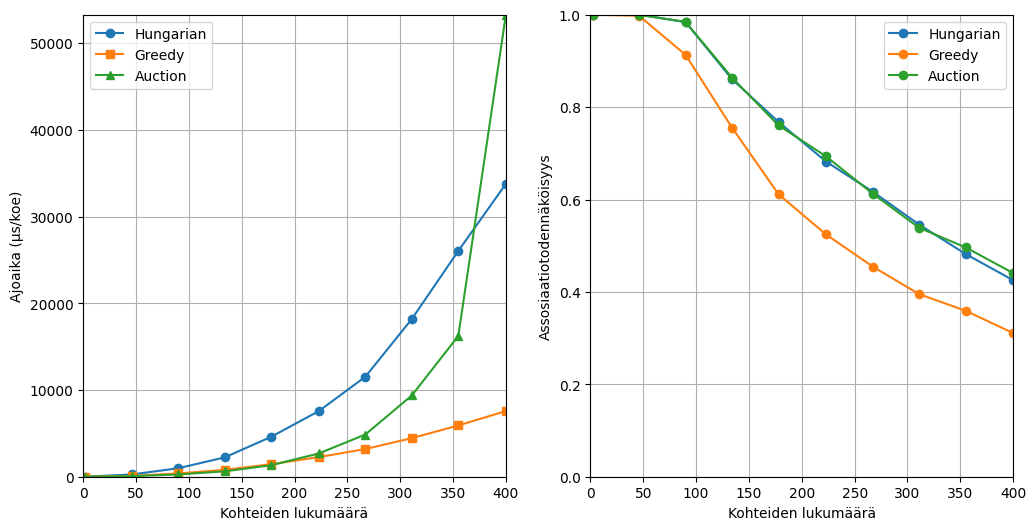

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors = ['red', 'blue', 'green', 'yellow']

for i, solver in enumerate(solvers):
    ax1.plot(target_counts, runtime_data[solver], label=solver.capitalize(), marker=markers[i % len(markers)])

ax1.set_xlabel("Kohteiden lukumäärä")
ax1.set_ylabel("Ajoaika (μs/koe)")
ax1.set_ylim(0, max(max(times) for times in runtime_data.values() if times))
ax1.set_xlim(0, max(target_counts))
ax1.legend()
ax1.grid()

for solver in solvers:
    ax2.plot(target_counts, accuracy_data[solver], marker='o', label=solver.capitalize())

ax2.set_xlabel("Kohteiden lukumäärä")
ax2.set_ylabel("Assosiaatiotodennäköisyys")
ax2.set_ylim(0, 1)
ax2.set_xlim(0, max(target_counts))
ax2.legend()
ax2.grid()


plt.show()

We can see that With low target numbers, the impact of algorithm choice on runtime is neglible. Thus, we focus only on the optimal solver aka the Hungarian. 

The accuracy chart is a bit misleading, as the choice of target separations and observer std is arbitrary. We can however infer that it seems like the optimal solution is similar to the unoptimal greedy solution with low target numbers. As target count increases, the runtime of the optimal and epsilon optimal algorithms increase.

Also we can clearly see that when the observation space of the observer is saturated, the epsilon-optimal auction starts to perform substantially worse than the optimal algorithm due to the selection of epsilon.

# Scenario geometry and association accuracy

## One observer 

Next, we shall observe how the target-observer-geometry affects the association accuracy with two predetermined scenarios. This shall be done by dividing an area of interest around the targets and calculating numerical the association accuracy in each cell.  

Scenarios:
* diamond 

In [10]:
diamond_targets = [
    (0, 1.0),
    (0.5, 0),
    (0, -1.0),
    (-0.5, 0),
]
line_targets = [
    (0, -0.75),
    (0, -0.25),
    (0, 0.25),
    (0, 0.75)
]

## One observer

In [11]:
def heatmap_single_observer(targets, sigma, grid_resolution=120, trials=1000,
                              x_limits=(-20.0, 20.0), y_limits=(-20.0, 20.0)):
    xs = np.linspace(x_limits[0], x_limits[1], grid_resolution)
    ys = np.linspace(y_limits[0], y_limits[1], grid_resolution)
    jobs = [
        ([(sx, sy, sigma)], targets, trials)
        for sy in ys for sx in xs
    ]
    rates = [_mc_worker(job) for job in jobs]
    return np.array(rates).reshape(grid_resolution, grid_resolution), xs, ys


def heatmap_two_observers(fixed_observer, targets, sigma, grid_resolution=120, trials=1000,
                           x_limits=(-20.0, 20.0), y_limits=(-20.0, 20.0)):
    xs = np.linspace(x_limits[0], x_limits[1], grid_resolution)
    ys = np.linspace(y_limits[0], y_limits[1], grid_resolution)
    fx, fy = fixed_observer
    jobs = [
        ([(fx, fy, sigma), (sx, sy, sigma)], targets, trials)
        for sy in ys for sx in xs
    ]
    rates = [_mc_worker(job) for job in jobs]
    return np.array(rates).reshape(grid_resolution, grid_resolution), xs, ys


def plot_sigma_heatmaps(targets, sigmas, fixed_observer=None, grid_resolution=120,
                        trials=1000, x_limits=(-20.0, 20.0), y_limits=(-20.0, 20.0),
                        title_prefix="", show_collinearity_axes=True):
    fig, axes = plt.subplots(2, 2, figsize=(11, 11), sharex=True, sharey=True)
    axes = axes.flatten()
    ims = []

    collinearity_lines = []
    if show_collinearity_axes:
        for i in range(len(targets)):
            for j in range(i + 1, len(targets)):
                x1, y1 = targets[i]
                x2, y2 = targets[j]
                dx, dy = x2 - x1, y2 - y1
                pts = []
                if dx != 0:
                    for xb in x_limits:
                        t = (xb - x1) / dx
                        yb = y1 + t * dy
                        if y_limits[0] <= yb <= y_limits[1]:
                            pts.append((xb, yb))
                if dy != 0:
                    for yb in y_limits:
                        t = (yb - y1) / dy
                        xb = x1 + t * dx
                        if x_limits[0] <= xb <= x_limits[1]:
                            pts.append((xb, yb))
                pts = list(dict.fromkeys(pts))
                if len(pts) >= 2:
                    collinearity_lines.append((pts[0], pts[1]))

    for ax, sigma in zip(axes, sigmas):
        if fixed_observer is None:
            grid, xs, ys = heatmap_single_observer(targets, sigma, grid_resolution,
                                                    trials, x_limits, y_limits)
        else:
            grid, xs, ys = heatmap_two_observers(fixed_observer, targets, sigma,
                                                  grid_resolution, trials, x_limits, y_limits)
        vmax = 1.0
        im = ax.imshow(grid, origin="lower",
                       extent=[x_limits[0], x_limits[1], y_limits[0], y_limits[1]],
                       cmap="viridis", vmin=0.5, vmax=vmax,
                       interpolation="bilinear", aspect="equal")
        ims.append(im)

        if show_collinearity_axes:
            for (x0, y0), (x1, y1) in collinearity_lines:
                ax.plot([x0, x1], [y0, y1],
                        color="red", alpha=0.5, linewidth=0.8,
                        linestyle="--", zorder=4)

        tx = [t[0] for t in targets]
        ty = [t[1] for t in targets]
        ax.scatter(tx, ty, color="white", edgecolors="black", s=30, zorder=5, label="Kohde")
        if fixed_observer is not None:
            ax.scatter(fixed_observer[0], fixed_observer[1], marker="^", s=200,
                       color="orange", edgecolors="black", zorder=5,
                       label="Kiinteä $S_1$")
        ax.set_title(f"{title_prefix}$\\sigma = {math.degrees(sigma):.0f}°$", fontsize=11)
        ax.set_xlabel("x-sijainti")
        ax.set_ylabel("y-sijainti")
        ax.legend(loc="upper right", fontsize=7)

    cbar = fig.colorbar(ims[-1], ax=axes, orientation='vertical', fraction=.05,
                         label=r"Assosiaatiotodenääköisyys")
    cbar.ax.yaxis.label.set_size(11)
    return fig

def _mc_worker(args):
    observers, targets, trials = args
    import bearing_simulation
    rate, _ = bearing_simulation.monte_carlo(observers, targets, trials, "hungarian")
    return rate

### Diamond targets, one observer

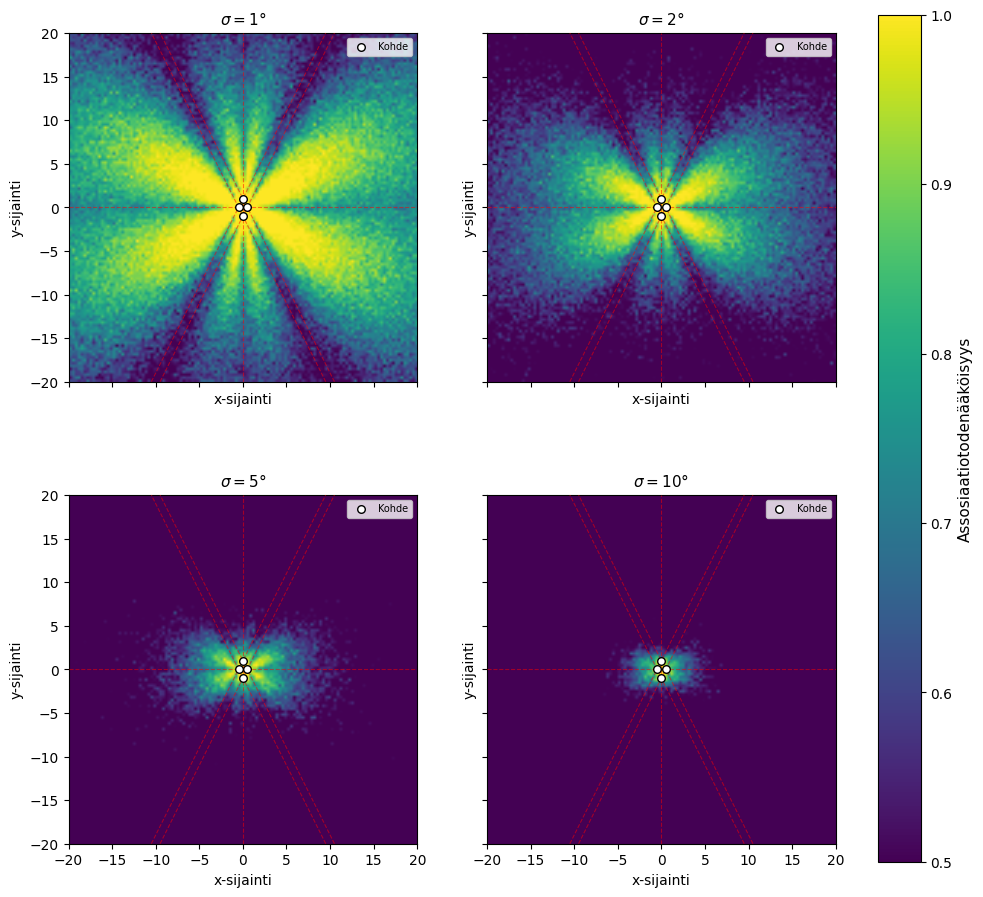

In [12]:
observer_stds_heatmap = [math.radians(1), math.radians(2), math.radians(5), math.radians(10)]
fig = plot_sigma_heatmaps(diamond_targets, observer_stds_heatmap,
                           grid_resolution=120, trials=50)
plt.show()

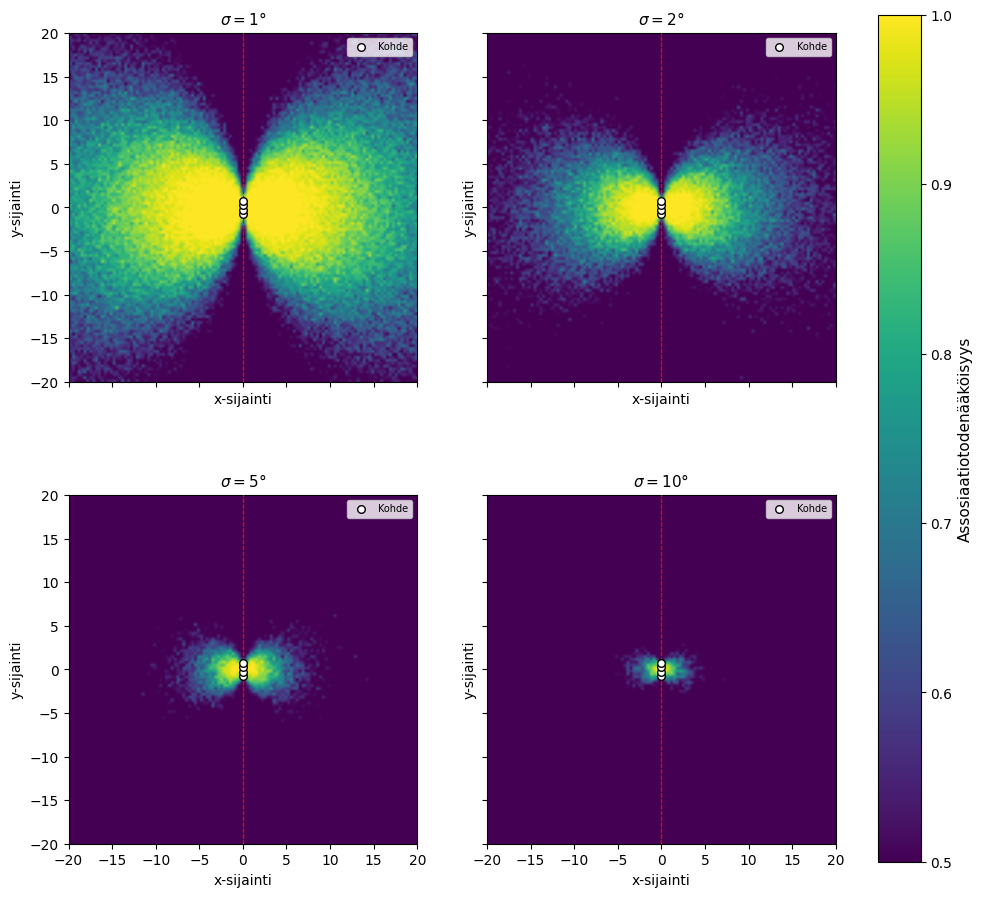

In [13]:
fig = plot_sigma_heatmaps(line_targets, observer_stds_heatmap,
                           grid_resolution=120, trials=50)
plt.show()

### Diamond targets, two observers (one fixed south of targets)

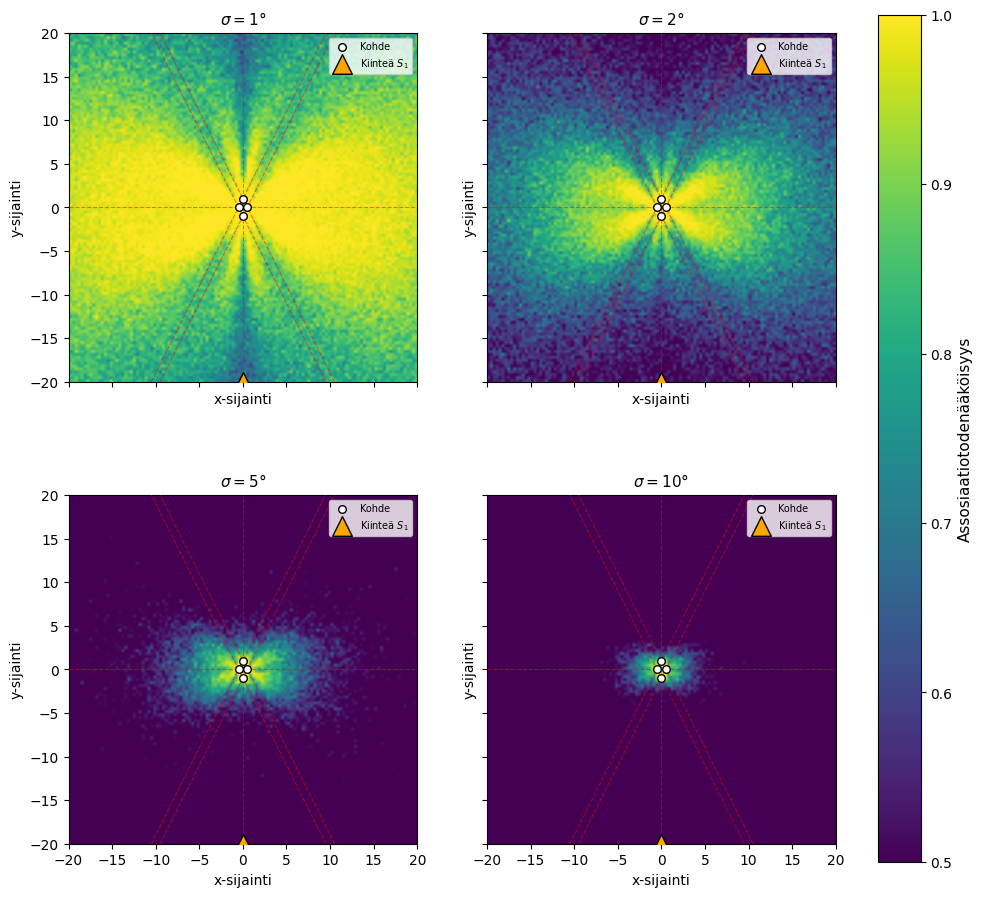

In [14]:
fixed_observer_xy = (0.0, -20.0)
fig = plot_sigma_heatmaps(diamond_targets, observer_stds_heatmap,
                           fixed_observer=fixed_observer_xy,
                           grid_resolution=120, trials=50)
plt.show()

### Line targets, two observers (one fixed south of targets)

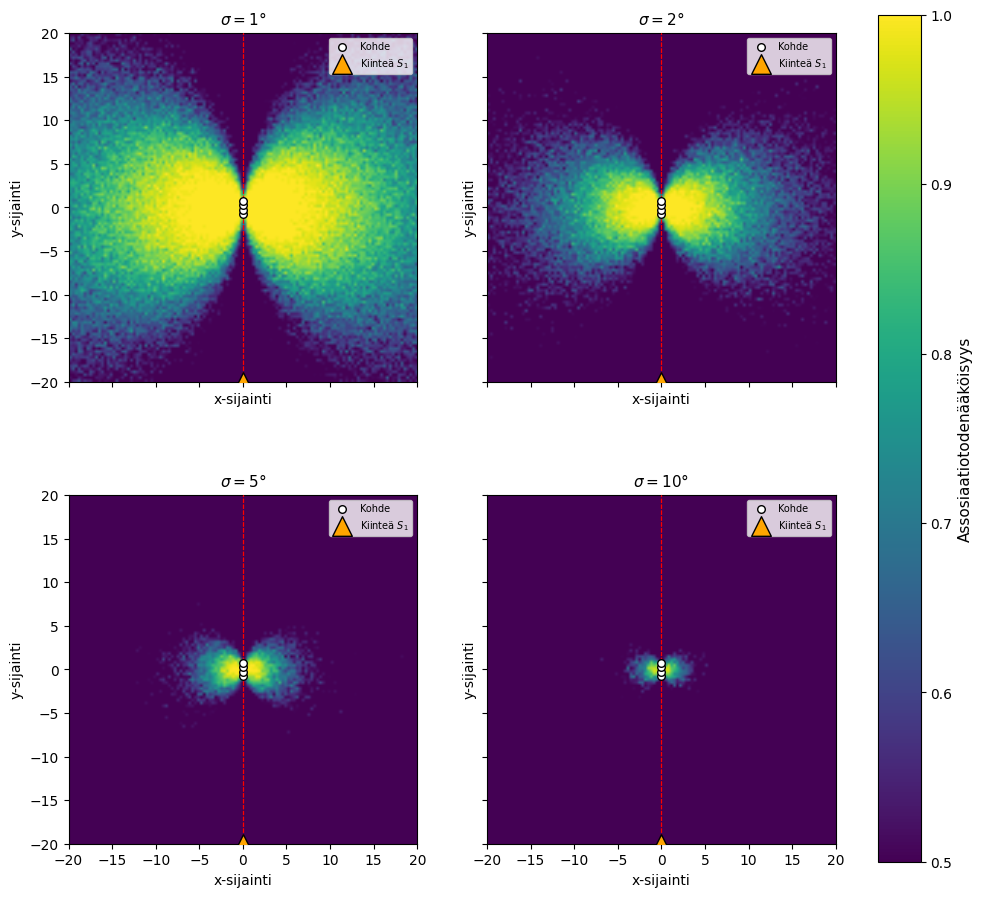

In [15]:
fixed_observer_xy = (0.0, -20.0)
fig = plot_sigma_heatmaps(line_targets, observer_stds_heatmap,
                           fixed_observer=fixed_observer_xy,
                           grid_resolution=120, trials=50)
plt.show()

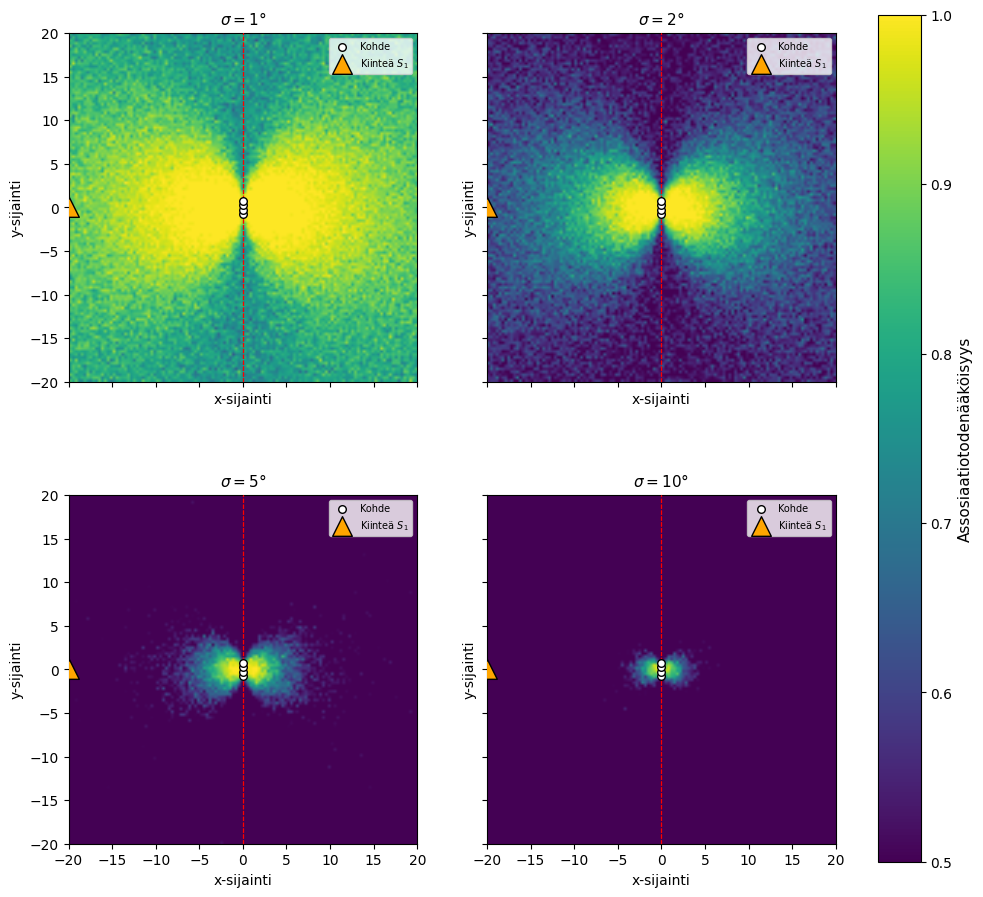

In [16]:
fixed_observer_xy = (-20.0, 0.0)
fig = plot_sigma_heatmaps(line_targets, observer_stds_heatmap,
                           fixed_observer=fixed_observer_xy,
                           grid_resolution=120, trials=50)
plt.show()

Adding observers (obviously) has a beneficiary effect for the association accuracy. However, no (reasonable) amount of observers can solve the association with poor geometry. Even with unlimited resources, the one dimensional nature of our measurements does not allow for arbitrarily poor observer placement. This is very obvious in the line scenario, where the collinear fixed sensor does not have an affect on the total association accuracy at all.

# Observer placement

In [17]:
def bearing_fim(observers, target):
    tx, ty = target
    fisher = np.zeros((2, 2))
    for sx, sy, std in observers:
        dx = tx - sx
        dy = ty - sy
        r2 = dx * dx + dy * dy
        g = np.array([-dy / r2, dx / r2])
        fisher += np.outer(g, g) / (std * std)
    return fisher


def crb_a_opt(observers, targets):
    total = 0.0
    for t in targets:
        fisher = bearing_fim(observers, t)
        det = fisher[0, 0] * fisher[1, 1] - fisher[0, 1] * fisher[1, 0]
        if det < 1e-12 * (fisher[0, 0] + fisher[1, 1]) ** 2:
            return math.inf
        total += np.trace(np.linalg.inv(fisher))
    return total


## Two targets

In [18]:
def angular_separation(observer_xy, t1, t2):
    sx, sy = observer_xy
    a1 = math.atan2(t1[1] - sy, t1[0] - sx)
    a2 = math.atan2(t2[1] - sy, t2[0] - sx)
    d = a1 - a2
    # wrap
    while d > math.pi:
        d -= 2 * math.pi
    while d <= -math.pi:
        d += 2 * math.pi
    return d


def D2_two_targets(observers_xy, t1, t2):
    return sum(angular_separation(o, t1, t2) ** 2 for o in observers_xy)


def P_correct_two_targets(observers_xy, t1, t2, sigma):
    D = math.sqrt(D2_two_targets(observers_xy, t1, t2))
    return float(norm.cdf(D / (sigma * math.sqrt(2))))


### Arc placement, two targets

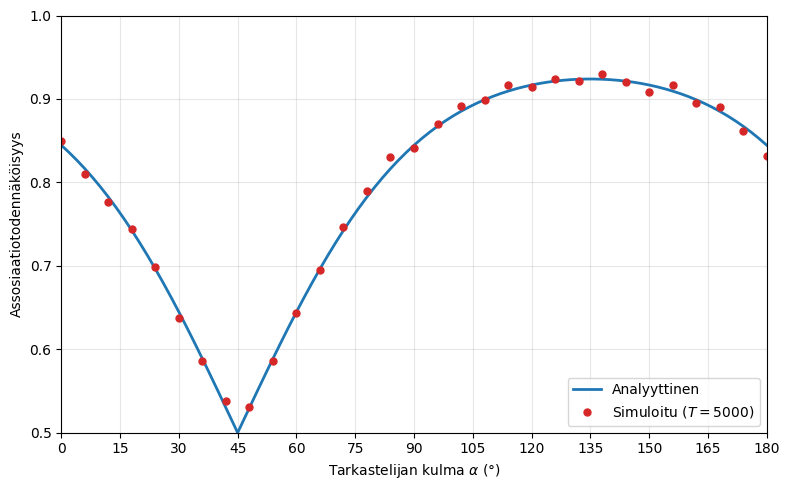

In [20]:
sigma_2t = math.radians(2)
R_arc = 20.0
a_target = 0.5
two_targets = [(a_target, a_target), (-a_target, -a_target)]

alphas = np.linspace(0.0, np.pi, 181)
P_analytical = np.array([
    P_correct_two_targets([(R_arc * math.cos(a), R_arc * math.sin(a))], *two_targets, sigma_2t)
    for a in alphas
])
P_smallA = np.array([
    float(norm.cdf((2 * a_target / R_arc) * abs(math.sin(a)) / (sigma_2t * math.sqrt(2))))
    for a in alphas
])

# MC verification at coarser resolution
trials_mc = 5000
alphas_mc = np.linspace(0.0, np.pi, 31)
jobs = [
    ([(R_arc * math.cos(a), R_arc * math.sin(a), sigma_2t)], two_targets, trials_mc)
    for a in alphas_mc
]
rates = [_mc_worker(job) for job in jobs]
P_mc = np.array(rates)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.degrees(alphas), P_analytical, "-", color="tab:blue", linewidth=2, label=r"Analyyttinen")
ax.plot(np.degrees(alphas_mc), P_mc, "o", color="tab:red", markersize=5, label=fr"Simuloitu ($T={trials_mc}$)")
ax.set_xlabel(r"Tarkastelijan kulma $\alpha$ (°)")
ax.set_xlim(0, 180)
ax.set_ylabel(r"Assosiaatiotodennäköisyys")
ax.set_ylim(0.5, 1.00)
ax.legend(loc="lower right")
ax.xaxis.set_major_locator(MultipleLocator(15))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Verification: line placement, two targets

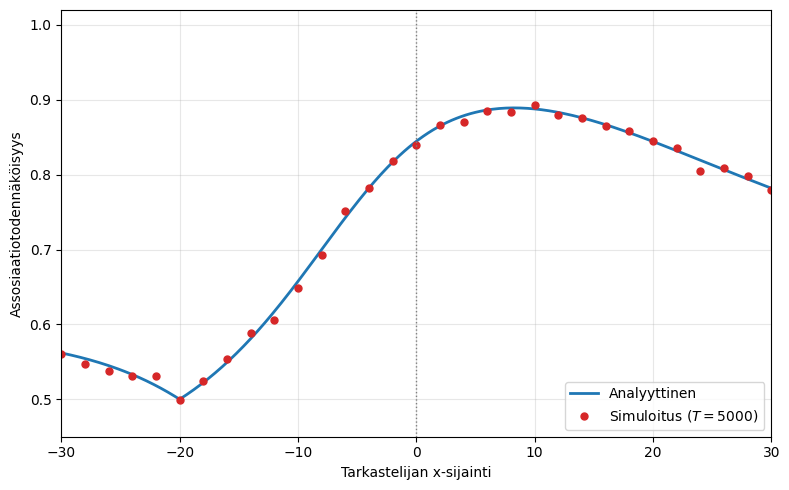

In [19]:
line_y_2t = -R_arc
xs_line = np.linspace(-30.0, 30.0, 301)
P_analytical_line = np.array([
    P_correct_two_targets([(x, line_y_2t)], *two_targets, sigma_2t)
    for x in xs_line
])
P_smallA_line = np.array([
    float(norm.cdf((2 * a_target * R_arc / (x ** 2 + R_arc ** 2)) / (sigma_2t * math.sqrt(2))))
    for x in xs_line
])

xs_mc = np.linspace(-30.0, 30.0, 31)
jobs = [([(x, line_y_2t, sigma_2t)], two_targets, trials_mc) for x in xs_mc]
rates = [_mc_worker(job) for job in jobs]
P_mc_line = np.array(rates)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs_line, P_analytical_line, "-", color="tab:blue", linewidth=2, label=r"Analyyttinen")
ax.plot(xs_mc, P_mc_line, "o", color="tab:red", markersize=5, label=fr"Simuloitus ($T={trials_mc}$)")
ax.axvline(0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel(r"Tarkastelijan x-sijainti")
ax.set_xlim(-30, 30)
ax.set_ylabel(r"Assosiaatiotodennäköisyys")
ax.set_ylim(0.45, 1.02)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

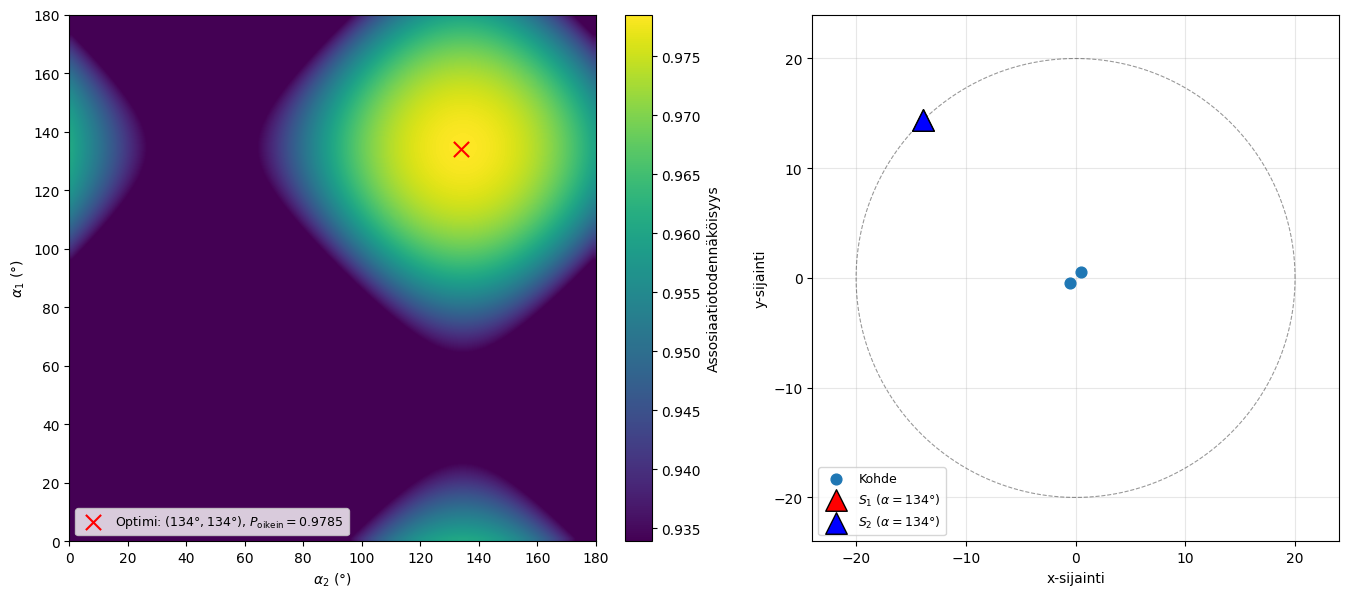

In [20]:
alpha_grid = np.linspace(0.0, np.pi, 91)
P_grid = np.zeros((len(alpha_grid), len(alpha_grid)))
for i, a1 in enumerate(alpha_grid):
    for j, a2 in enumerate(alpha_grid):
        obs = [(R_arc * math.cos(a1), R_arc * math.sin(a1)),
               (R_arc * math.cos(a2), R_arc * math.sin(a2))]
        P_grid[i, j] = P_correct_two_targets(obs, *two_targets, sigma_2t)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
im = ax.imshow(P_grid, origin="lower",
               extent=[np.degrees(alpha_grid[0]), np.degrees(alpha_grid[-1])] * 2,
               cmap="viridis", vmin=float(np.percentile(P_grid, 60)), vmax=P_grid.max(),
               aspect="equal", interpolation="bilinear")
i_opt, j_opt = np.unravel_index(np.argmax(P_grid), P_grid.shape)
ax.scatter(np.degrees(alpha_grid[j_opt]), np.degrees(alpha_grid[i_opt]),
           marker="x", color="red", s=120, zorder=5,
           label=fr"Optimi: $({np.degrees(alpha_grid[i_opt]):.0f}°, "
                 fr"{np.degrees(alpha_grid[j_opt]):.0f}°)$, "
                 fr"$P_{{\mathrm{{oikein}}}}={P_grid.max():.4f}$")
ax.set_xlabel(r"$\alpha_2$ (°)")
ax.set_ylabel(r"$\alpha_1$ (°)")
ax.legend(loc="lower left", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, label=r"Assosiaatiotodennäköisyys")

ax = axes[1]
a_full = np.linspace(0, 2 * np.pi, 200)
ax.plot(R_arc * np.cos(a_full), R_arc * np.sin(a_full), "--", color="black",
        alpha=0.4, linewidth=0.8)
ax.scatter([t[0] for t in two_targets], [t[1] for t in two_targets],
           color="tab:blue", s=60, zorder=5, label="Kohde")
for n_idx, alpha_opt in enumerate([alpha_grid[i_opt], alpha_grid[j_opt]]):
    sx = R_arc * math.cos(alpha_opt)
    sy = R_arc * math.sin(alpha_opt)
    ax.scatter(sx, sy, marker="^", s=240, color=colors[n_idx], edgecolors="black",
               zorder=6, label=fr"$S_{{{n_idx + 1}}}$ ($\alpha={np.degrees(alpha_opt):.0f}°$)")
ax.set_xlim(-R_arc * 1.2, R_arc * 1.2)
ax.set_ylim(-R_arc * 1.2, R_arc * 1.2)
ax.set_aspect("equal")
ax.set_xlabel("x-sijainti")
ax.set_ylabel("y-sijainti")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

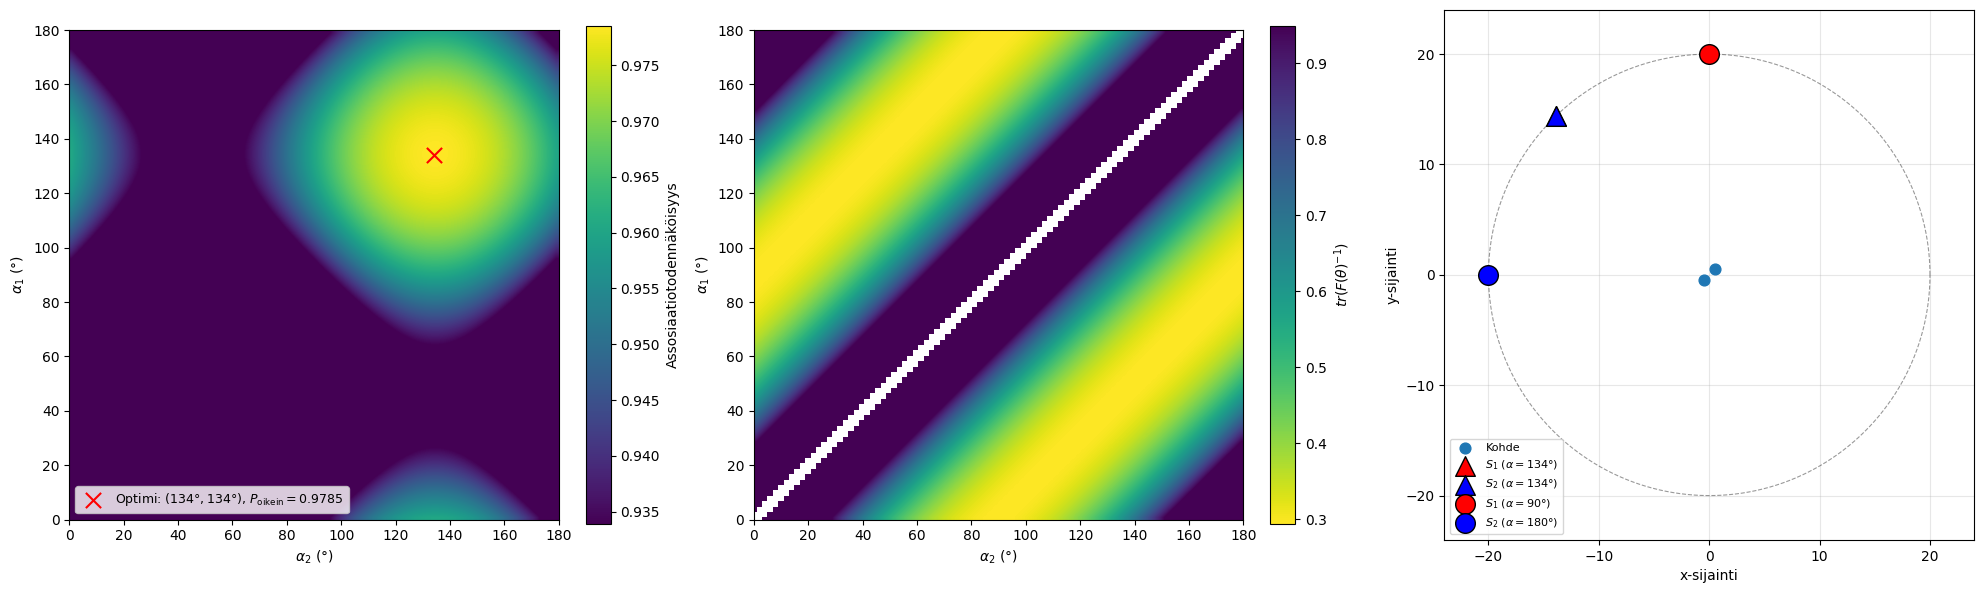

In [21]:
alpha_grid = np.linspace(0.0, np.pi, 91)
P_grid = np.zeros((len(alpha_grid), len(alpha_grid)))
A_grid = np.full((len(alpha_grid), len(alpha_grid)), np.inf)
for i, a1 in enumerate(alpha_grid):
    for j, a2 in enumerate(alpha_grid):
        obs_xy = [(R_arc * math.cos(a1), R_arc * math.sin(a1)),
                  (R_arc * math.cos(a2), R_arc * math.sin(a2))]
        P_grid[i, j] = P_correct_two_targets(obs_xy, *two_targets, sigma_2t)
        obs_with_std = [(*obs_xy[0], sigma_2t), (*obs_xy[1], sigma_2t)]
        A_grid[i, j] = crb_a_opt(obs_with_std, two_targets)

i_opt_P, j_opt_P = np.unravel_index(np.argmax(P_grid), P_grid.shape)
A_finite = np.where(np.isfinite(A_grid), A_grid, np.nan)
i_opt_A, j_opt_A = np.unravel_index(np.nanargmin(A_finite), A_finite.shape)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
im = ax.imshow(P_grid, origin="lower",
               extent=[np.degrees(alpha_grid[0]), np.degrees(alpha_grid[-1])] * 2,
               cmap="viridis", vmin=float(np.percentile(P_grid, 60)), vmax=P_grid.max(),
               aspect="equal", interpolation="bilinear")
ax.scatter(np.degrees(alpha_grid[j_opt_P]), np.degrees(alpha_grid[i_opt_P]),
           marker="x", color="red", s=120, zorder=5,
           label=fr"Optimi: $({np.degrees(alpha_grid[i_opt_P]):.0f}°, "
                 fr"{np.degrees(alpha_grid[j_opt_P]):.0f}°)$, "
                 fr"$P_{{\mathrm{{oikein}}}}={P_grid.max():.4f}$")
ax.set_xlabel(r"$\alpha_2$ (°)")
ax.set_ylabel(r"$\alpha_1$ (°)")
ax.legend(loc="lower left", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, label=r"Assosiaatiotodennäköisyys")

ax = axes[1]
A_log = np.log10(A_finite)
im = ax.imshow(A_log, origin="lower",
               extent=[np.degrees(alpha_grid[0]), np.degrees(alpha_grid[-1])] * 2,
               cmap="viridis_r",
               vmin=float(np.nanpercentile(A_log, 5)),
               vmax=float(np.nanpercentile(A_log, 70)),
               aspect="equal", interpolation="bilinear")
ax.set_xlabel(r"$\alpha_2$ (°)")
ax.set_ylabel(r"$\alpha_1$ (°)")
fig.colorbar(im, ax=ax, fraction=0.046,
             label=r"$tr(F(\theta)^{-1})$")

ax = axes[2]
a_full = np.linspace(0, 2 * np.pi, 200)
ax.plot(R_arc * np.cos(a_full), R_arc * np.sin(a_full), "--", color="black",
        alpha=0.4, linewidth=0.8)
ax.scatter([t[0] for t in two_targets], [t[1] for t in two_targets],
           color="tab:blue", s=60, zorder=5, label="Kohde")

for n_idx, alpha_opt in enumerate([alpha_grid[i_opt_P], alpha_grid[j_opt_P]]):
    sx = R_arc * math.cos(alpha_opt)
    sy = R_arc * math.sin(alpha_opt)
    ax.scatter(sx, sy, marker="^", s=200, color=colors[n_idx], edgecolors="black",
               zorder=6,
               label=fr"$S_{{{n_idx + 1}}}$ ($\alpha={np.degrees(alpha_opt):.0f}°$)")

for n_idx, alpha_opt in enumerate([alpha_grid[i_opt_A], alpha_grid[j_opt_A]]):
    sx = R_arc * math.cos(alpha_opt)
    sy = R_arc * math.sin(alpha_opt)
    ax.scatter(sx, sy, marker="o", s=200, color=colors[n_idx], edgecolors="black", zorder=7,
               label=fr"$S_{{{n_idx + 1}}}$ ($\alpha={np.degrees(alpha_opt):.0f}°$)")

ax.set_xlim(-R_arc * 1.2, R_arc * 1.2)
ax.set_ylim(-R_arc * 1.2, R_arc * 1.2)
ax.set_aspect("equal")
ax.set_xlabel("x-sijainti")
ax.set_ylabel("y-sijainti")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


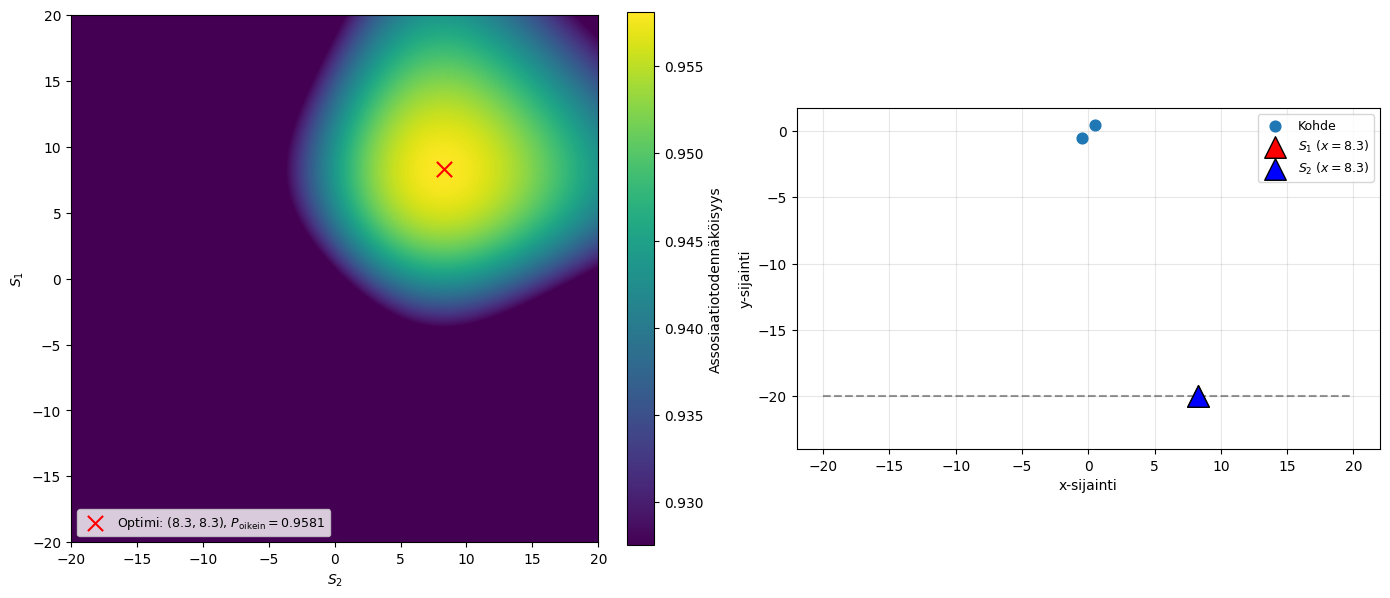

In [22]:
line_y_4t = -20.0
x_lim = (-20.0, 20.0)
path_resolution_line = 100

xs_cand = np.linspace(x_lim[0], x_lim[1], path_resolution_line)

P_grid_line = np.full((path_resolution_line, path_resolution_line), np.nan)

for i, x1 in enumerate(xs_cand):
    for j, x2 in enumerate(xs_cand):
        obs = [(x1, line_y_4t), (x2, line_y_4t)]
        P_grid_line[i, j] = P_correct_two_targets(obs, *two_targets, sigma_2t)

i_opt, j_opt = np.unravel_index(np.nanargmax(P_grid_line), P_grid_line.shape)
P_max_line = P_grid_line[i_opt, j_opt]

extent_line = [xs_cand[0], xs_cand[-1], xs_cand[0], xs_cand[-1]]

vmin_line = float(np.nanpercentile(P_grid_line, 70.0))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]

im = ax.imshow(P_grid_line, origin="lower", extent=extent_line, cmap="viridis",
               vmin=vmin_line, vmax=P_max_line, aspect="equal", interpolation="bilinear",)

ax.scatter(xs_cand[j_opt], xs_cand[i_opt], marker="x", color="red", s=120,
           zorder=5, label=fr"Optimi: $({xs_cand[i_opt]:.1f}, {xs_cand[j_opt]:.1f})$, $P_\mathrm{{oikein}}={P_max_line:.4f}$")
ax.set_xlabel(r"$S_2$")
ax.set_ylabel(r"$S_1$")
ax.legend(loc="lower left", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, label=r"Assosiaatiotodennäköisyys")


ax = axes[1]
ax.plot([x_lim[0], x_lim[1]], [line_y_4t, line_y_4t], "--", color="black", alpha=0.4)

ax.scatter([t[0] for t in two_targets], [t[1] for t in two_targets], color="tab:blue",
           s=60, zorder=5, label="Kohde")

for n_idx, x_opt in enumerate([xs_cand[i_opt], xs_cand[j_opt]]):
    ax.scatter(x_opt, line_y_4t, marker="^", s=240, color=colors[n_idx],
               edgecolors="black", zorder=6, label=fr"$S_{{{n_idx+1}}}$ ($x={x_opt:.1f}$)")
ax.set_xlim(x_lim[0] * 1.1, x_lim[1] * 1.1)
ax.set_ylim(line_y_4t * 1.2, max(t[1] for t in two_targets) * 1.5 + 1)
ax.set_aspect("equal")
ax.set_xlabel("x-sijainti")
ax.set_ylabel("y-sijainti")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

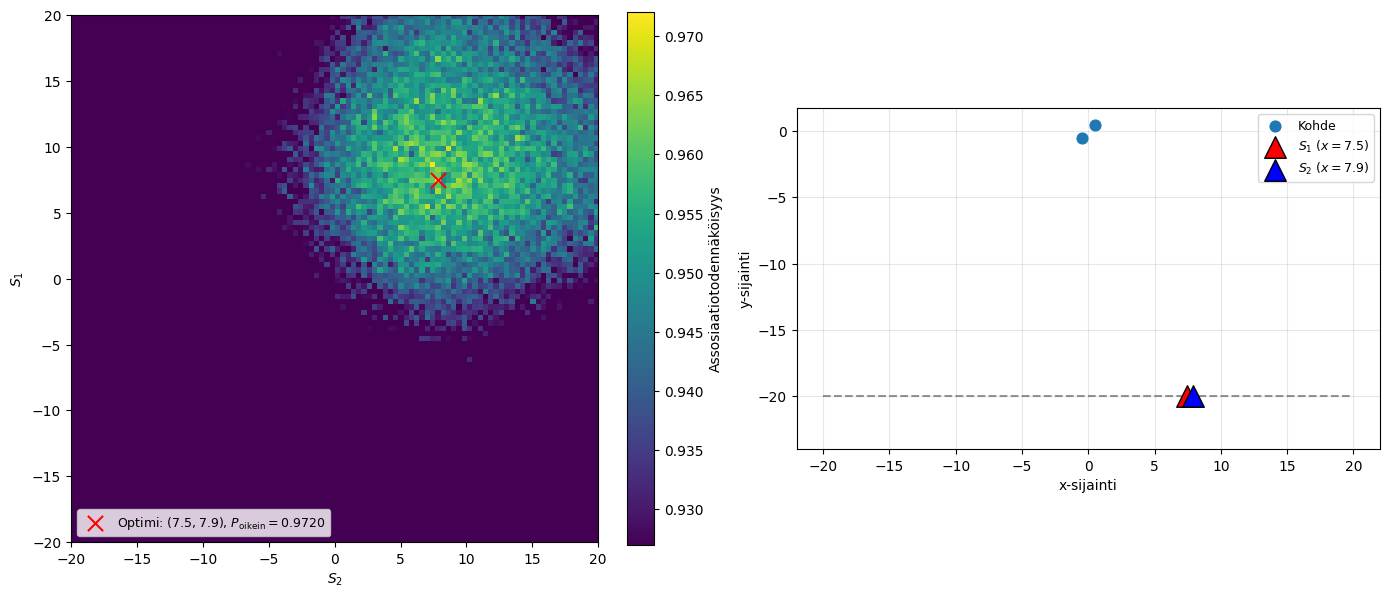

In [23]:
line_y_4t = -20.0
x_lim = (-20.0, 20.0)
path_resolution_line = 100
xs_cand = np.linspace(x_lim[0], x_lim[1], path_resolution_line)
trials_line = 2000
jobs = []

for x1 in xs_cand:
    for x2 in xs_cand:
        obs = [(x1, line_y_4t, sigma_2t), (x2, line_y_4t, sigma_2t)]
        jobs.append((obs, two_targets, trials_line))

rates = [_mc_worker(job) for job in jobs]
P_grid_emp_line = np.array(rates).reshape(path_resolution_line,path_resolution_line)
i_opt, j_opt = np.unravel_index(np.nanargmax(P_grid_emp_line), P_grid_emp_line.shape)
P_max_emp_line = P_grid_emp_line[i_opt, j_opt]
extent_line = [xs_cand[0], xs_cand[-1], xs_cand[0], xs_cand[-1]]
vmin_line = float(np.nanpercentile(P_grid_emp_line, 70.0))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]

im = ax.imshow(P_grid_emp_line, origin="lower", extent=extent_line, cmap="viridis",
               vmin=vmin_line, vmax=P_max_emp_line, aspect="equal", interpolation="nearest")

ax.scatter(xs_cand[j_opt], xs_cand[i_opt], marker="x", color="red", s=120, zorder=5,
           label=fr"Optimi: $({xs_cand[i_opt]:.1f}, {xs_cand[j_opt]:.1f})$, $P_\mathrm{{oikein}}={P_max_emp_line:.4f}$")
ax.set_xlabel(r"$S_2$")
ax.set_ylabel(r"$S_1$")
ax.legend(loc="lower left", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, label="Assosiaatiotodennäköisyys")

ax = axes[1]

ax.plot([x_lim[0], x_lim[1]], [line_y_4t, line_y_4t], "--", color="black", alpha=0.4)
ax.scatter([t[0] for t in two_targets], [t[1] for t in two_targets], color="tab:blue",
           s=60, zorder=5, label="Kohde")

for n_idx, x_opt in enumerate([xs_cand[i_opt], xs_cand[j_opt]]):
    ax.scatter(x_opt, line_y_4t, marker="^", s=240, color=colors[n_idx],
               edgecolors="black", zorder=6, label=fr"$S_{{{n_idx+1}}}$ ($x={x_opt:.1f}$)")
ax.set_xlim(x_lim[0] * 1.1, x_lim[1] * 1.1)
ax.set_ylim(line_y_4t * 1.2, max(t[1] for t in two_targets) * 1.5 + 1)
ax.set_aspect("equal")
ax.set_xlabel("x-sijainti")
ax.set_ylabel("y-sijainti")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Four targets

In [24]:
def D2_per_pair(observers_xy, targets):
    pairs = []
    for i in range(len(targets)):
        for j in range(i + 1, len(targets)):
            D2 = sum(angular_separation(o, targets[i], targets[j]) ** 2 for o in observers_xy)
            pairs.append((i, j, D2))
    return pairs

### Diamond, K=2, arc placement

In [25]:
import time

K = 2
sigma_4t = math.radians(2)
radius_4t = 20.0
path_resolution_arc = 90
trials_arc = 10000

observer_angles = np.linspace(0.0, np.pi, path_resolution_arc, endpoint=False)
candidate_arc = [(radius_4t * math.cos(a), radius_4t * math.sin(a)) for a in observer_angles]

ij_list = [(i, j) for i in range(path_resolution_arc) for j in range(i + 1, path_resolution_arc)]

print(f"Arc K=2: {len(ij_list)} configurations x {trials_arc} trials = {len(ij_list) * trials_arc:.2e} MC samples")

jobs = [([(*candidate_arc[i], sigma_4t), (*candidate_arc[j], sigma_4t)], diamond_targets, trials_arc) for (i, j) in ij_list]
t0 = time.time()
acc_flat = [_mc_worker(job) for job in jobs]
print(f"MC done in {time.time() - t0:.1f}s ({(time.time()-t0)/len(jobs)*1000:.1f} ms/config)")

acc_grid = np.full((path_resolution_arc, path_resolution_arc), np.nan)
ub_grid = np.full((path_resolution_arc, path_resolution_arc), np.nan)
for (i, j), a in zip(ij_list, acc_flat):
    acc_grid[i, j] = a
    acc_grid[j, i] = a

Arc K=2: 4005 configurations x 10000 trials = 4.00e+07 MC samples
MC done in 83.9s (20.9 ms/config)


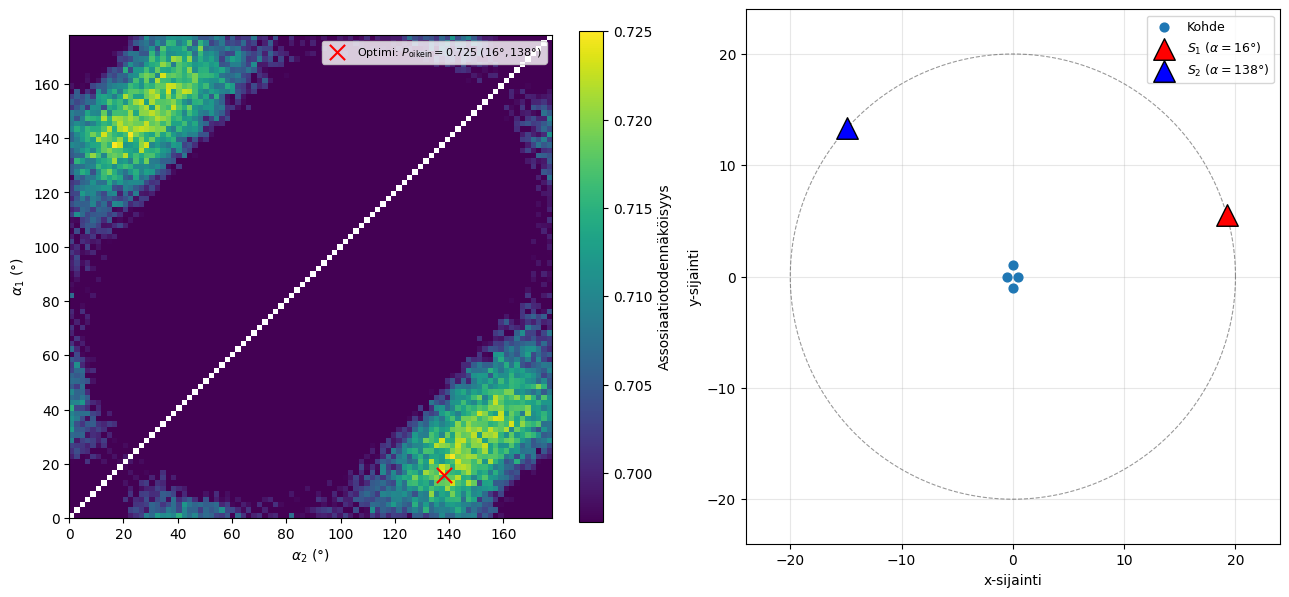

In [26]:
i_opt, j_opt = np.unravel_index(np.nanargmax(acc_grid), acc_grid.shape)
acc_max = acc_grid[i_opt, j_opt]

deg = np.degrees(observer_angles)
extent = [deg[0], deg[-1], deg[0], deg[-1]]

vmin_acc = float(np.nanpercentile(acc_grid, 70.0))

fig, axes = plt.subplots(1, 2, figsize=(13, 13))

ax = axes[0]
im = ax.imshow(acc_grid, origin="lower", extent=extent, cmap="viridis",
               vmin=vmin_acc, vmax=acc_max, aspect="equal", interpolation="nearest")
ax.scatter(deg[j_opt], deg[i_opt], marker="x", color="red", s=120, zorder=5,
           label=fr"Optimi: $P_\mathrm{{oikein}} = {acc_max:.3f}$ "
                 fr"$({deg[i_opt]:.0f}°, {deg[j_opt]:.0f}°)$")
ax.set_xlabel(r"$\alpha_2$ (°)")
ax.set_ylabel(r"$\alpha_1$ (°)")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, label=r"Assosiaatiotodennäköisyys")

ax = axes[1]
a_full = np.linspace(0, 2 * np.pi, 200)
ax.plot(radius_4t * np.cos(a_full), radius_4t * np.sin(a_full), "--", color="black",
        alpha=0.4, linewidth=0.8)
ax.scatter([t[0] for t in diamond_targets], [t[1] for t in diamond_targets],
           color="tab:blue", s=40, zorder=5, label="Kohde")
for n_idx, k_idx in enumerate([i_opt, j_opt]):
    sx, sy = candidate_arc[k_idx]
    ax.scatter(sx, sy, marker="^", s=240, color=colors[n_idx], edgecolors="black",
               zorder=6, label=fr"$S_{{{n_idx + 1}}}$ ($\alpha={deg[k_idx]:.0f}°$)")
ax.set_xlim(-radius_4t * 1.2, radius_4t * 1.2)
ax.set_ylim(-radius_4t * 1.2, radius_4t * 1.2)
ax.set_aspect("equal")
ax.set_xlabel("x-sijainti")
ax.set_ylabel("y-sijainti")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Diamond, K=2, line placement

In [27]:
line_y_4t = -20.0
x_lim = (-20.0, 20.0)
path_resolution_line = 100

xs_cand = np.linspace(x_lim[0], x_lim[1], path_resolution_line)
candidate_line = [(x, line_y_4t) for x in xs_cand]

ij_list_line = [(i, j) for i in range(path_resolution_line) for j in range(i + 1, path_resolution_line)]
trials_line = 5000
jobs = [
    ([(*candidate_line[i], sigma_4t), (*candidate_line[j], sigma_4t)], diamond_targets, trials_line)
    for (i, j) in ij_list_line
]
t0 = time.time()
acc_flat_line = [_mc_worker(job) for job in jobs]
print(f"Line K=2: {len(jobs)} configs in {time.time() - t0:.1f}s")

acc_grid_line = np.full((path_resolution_line, path_resolution_line), np.nan)
for (i, j), a in zip(ij_list_line, acc_flat_line):
    acc_grid_line[i, j] = a
    acc_grid_line[j, i] = a

i_opt, j_opt = np.unravel_index(np.nanargmax(acc_grid_line), acc_grid_line.shape)
acc_max_line = acc_grid_line[i_opt, j_opt]

extent_line = [xs_cand[0], xs_cand[-1], xs_cand[0], xs_cand[-1]]
vmin_acc = float(np.nanpercentile(acc_grid_line, 70.0))

Line K=2: 4950 configs in 58.5s


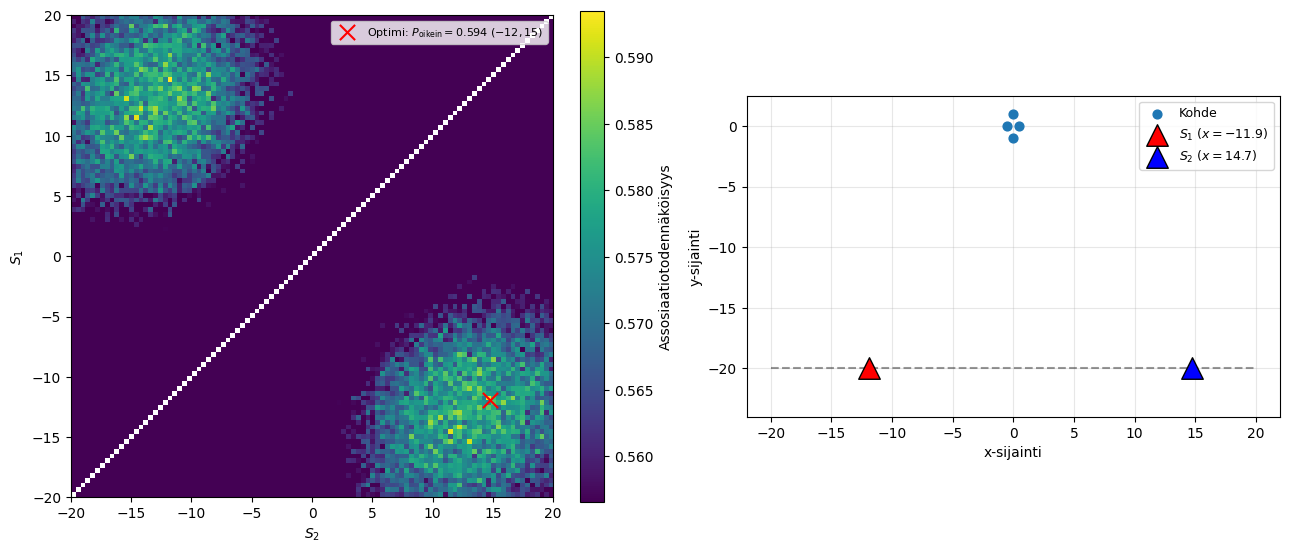

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 13))

ax = axes[0]
im = ax.imshow(acc_grid_line, origin="lower", extent=extent_line, cmap="viridis",
               vmin=vmin_acc, vmax=acc_max_line, aspect="equal", interpolation="nearest")
ax.scatter(xs_cand[j_opt], xs_cand[i_opt], marker="x", color="red", s=120, zorder=5,
           label=fr"Optimi: $P_\mathrm{{oikein}} = {acc_max_line:.3f}$ $({xs_cand[i_opt]:.0f}, {xs_cand[j_opt]:.0f})$")

ax.set_xlabel(r"$S_2$")
ax.set_ylabel(r"$S_1$")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, label=r"Assosiaatiotodennäköisyys")

ax = axes[1]
ax.plot([x_lim[0], x_lim[1]], [line_y_4t, line_y_4t], "--", color="black", alpha=0.4)
ax.scatter([t[0] for t in diamond_targets], [t[1] for t in diamond_targets],
           color="tab:blue", s=40, zorder=5, label="Kohde")
for n_idx, k_idx in enumerate([i_opt, j_opt]):
    sx, sy = candidate_line[k_idx]
    ax.scatter(sx, sy, marker="^", s=240, color=colors[n_idx], edgecolors="black",
               zorder=6, label=fr"$S_{{{n_idx + 1}}}$ ($x={sx:.1f}$)")
ax.set_xlim(x_lim[0] * 1.1, x_lim[1] * 1.1)
ax.set_ylim(line_y_4t * 1.2, max(t[1] for t in diamond_targets) * 1.5 + 1)
ax.set_aspect("equal")
ax.set_xlabel("x-sijainti")
ax.set_ylabel("y-sijainti")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Next, the effect of varying sigma and distance between the targets and the border is examined.

In [29]:
line_y_4t = -20.0
x_lim = (-20.0, 20.0)
path_resolution_line = 100
sigmas_deg = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
xs_cand = np.linspace(x_lim[0], x_lim[1], path_resolution_line)
candidate_line = [(x, line_y_4t) for x in xs_cand]
ij_list_line = [(i, j) for i in range(path_resolution_line) for j in range(i + 1, path_resolution_line)]
trials_line = 20000

result = []
for sigma_deg in sigmas_deg:
    sigma = math.radians(sigma_deg)
    jobs = [
        ([(*candidate_line[i], sigma), (*candidate_line[j], sigma)], diamond_targets, trials_line)
        for (i, j) in ij_list_line
    ]
    t0 = time.time()
    acc_flat_line = [_mc_worker(job) for job in jobs]
    print(f"sigma={sigma_deg}°: {len(jobs)} configs in {time.time() - t0:.1f}s")

    acc_grid_line = np.full((path_resolution_line, path_resolution_line), np.nan)
    for (i, j), a in zip(ij_list_line, acc_flat_line):
        acc_grid_line[i, j] = a
        acc_grid_line[j, i] = a

    i_opt, j_opt = np.unravel_index(np.nanargmax(acc_grid_line), acc_grid_line.shape)
    acc_max_line = acc_grid_line[i_opt, j_opt]
    x1, x2 = sorted([float(xs_cand[i_opt]), float(xs_cand[j_opt])])

    result.append({
        "sigma (°)": sigma_deg,
        "x1": round(x1, 2),
        "x2": round(x2, 2),
        "P_oikein": round(float(acc_max_line), 4),
    })

sigma=1°: 4950 configs in 215.1s
sigma=2°: 4950 configs in 214.4s
sigma=3°: 4950 configs in 195.8s
sigma=4°: 4950 configs in 222.6s
sigma=5°: 4950 configs in 224.9s
sigma=6°: 4950 configs in 228.6s
sigma=7°: 4950 configs in 238.3s
sigma=8°: 4950 configs in 208.7s
sigma=9°: 4950 configs in 210.9s
sigma=10°: 4950 configs in 210.8s


In [85]:
df_result = pd.DataFrame(result)
df_result

,sigma (°),x1,x2,P_oikein
0,1,-11.92,11.92,0.8903
1,2,-12.32,12.32,0.5877
2,3,-13.13,11.92,0.4608
3,4,-17.98,11.11,0.4024
4,5,-13.94,13.13,0.3700
5,6,-12.32,10.30,0.3482
6,7,-15.15,9.09,0.3333
7,8,-10.30,14.34,0.3228
8,9,-15.15,16.77,0.3153
9,10,-10.71,9.49,0.3089


In [101]:
line_y_4t = [-20.0, -25.0, -30.0, -35.0, -40.0, -45.0, -50.0, -55.0, -60.0, -65.0]
path_resolution_line = 100
sigma = math.radians(1)
trials_line = 20000
result = []
for line_y in line_y_4t:
    x_lim = (line_y, -line_y)
    xs_cand = np.linspace(x_lim[0], x_lim[1], path_resolution_line)
    ij_list_line = [(i, j) for i in range(path_resolution_line) for j in range(i + 1, path_resolution_line)]
    candidate_line = [(x, line_y) for x in xs_cand]

    jobs = [
        ([(*candidate_line[i], sigma), (*candidate_line[j], sigma)], diamond_targets, trials_line)
        for (i, j) in ij_list_line
    ]
    t0 = time.time()
    acc_flat_line = [_mc_worker(job) for job in jobs]
    print(f"line_y={line_y}: {len(jobs)} configs in {time.time() - t0:.1f}s")

    acc_grid_line = np.full((path_resolution_line, path_resolution_line), np.nan)
    for (i, j), a in zip(ij_list_line, acc_flat_line):
        acc_grid_line[i, j] = a
        acc_grid_line[j, i] = a

    i_opt, j_opt = np.unravel_index(np.nanargmax(acc_grid_line), acc_grid_line.shape)
    acc_max_line = acc_grid_line[i_opt, j_opt]
    x1, x2 = sorted([float(xs_cand[i_opt]), float(xs_cand[j_opt])])

    result.append({
        "d": abs(line_y),
        "x1": round(x1, 2),
        "x2": round(x2, 2),
        "rat": round(abs(x2 - x1) / abs(line_y), 3),
        "P_oikein": round(float(acc_max_line), 4),
    })

line_y=-20.0: 4950 configs in 220.1s
line_y=-25.0: 4950 configs in 233.9s
line_y=-30.0: 4950 configs in 215.2s
line_y=-35.0: 4950 configs in 223.0s
line_y=-40.0: 4950 configs in 215.0s
line_y=-45.0: 4950 configs in 200.8s
line_y=-50.0: 4950 configs in 202.2s
line_y=-55.0: 4950 configs in 201.6s
line_y=-60.0: 4950 configs in 201.3s
line_y=-65.0: 4950 configs in 201.0s


In [102]:
df_result = pd.DataFrame(result)
df_result

,d,x1,x2,rat,P_oikein
0,20.0,-10.71,13.54,1.212,0.8891
1,25.0,-18.43,16.41,1.394,0.7921
2,30.0,-16.06,19.70,1.192,0.7069
3,35.0,-23.69,22.98,1.333,0.6410
4,40.0,-23.84,31.92,1.394,0.5846
5,45.0,-30.45,29.55,1.333,0.5430
6,50.0,-37.88,32.83,1.414,0.5094
7,55.0,-38.33,37.22,1.374,0.4829
8,60.0,-35.76,45.45,1.354,0.4601
9,65.0,-43.99,47.93,1.414,0.4416
